code: [625,25]
Best State: [[ 0 15  0 20  0 30  0 30  1 21  1 23  1 25  1 31  2 15  2 22  2 26  2 32
   2 34  3 16  3 20  3 27  3 31  4 16  4 18  4 22  4 24  5 19  5 23  5 27
   5 32  6 17  6 17  6 20  6 27  7 22  7 28  7 33  7 33  8 17  8 23  8 29
   8 30  9 16  9 21  9 28  9 32 10 15 10 18 10 26 10 31 11 18 11 24 11 29
  11 34 12 19 12 21 12 26 12 34 13 24 13 25 13 28 13 33 14 19 14 25 14 29]]
Total runtime for [[625,25]]: 0.0h 54.0m 44.24006509780884s
Physical error rate p: 0.03, MC budget: 5e+04
Number of steps L: 10, neighbors per step (incl. initial) N: 50
logical error rate of initial state: 0.0053 ± 0.00032471573538431453
Best logical error rate found at step 233:
Best logical error rate found: 0.00284 ± 0.0002379912199985872
Initial state classical code parameters: [20, 5, 8]
Best state classical code parameters found: [20, 5, 8]
Number of valid neighbors per step (excluding initial): [0, 10, 10, 10, 10, 10, 10, 10, 4, 10]
------------------------------------------------------

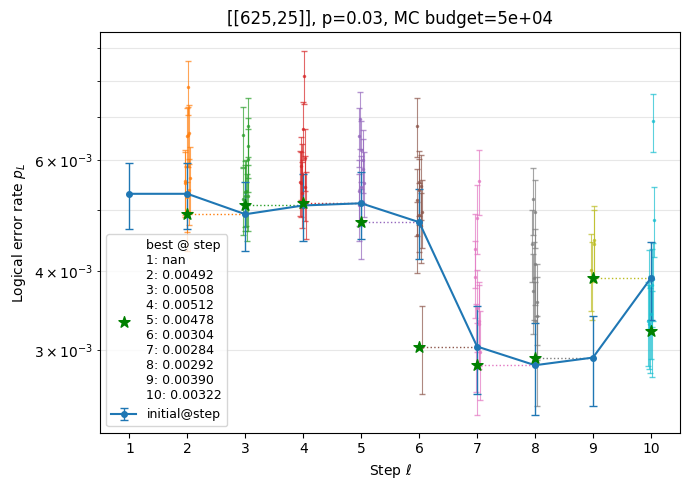

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import h5py

best_neighbor_search_path = './optimization/results/fast_greedy_start_from_d_best_2_single_parent_excluding_parents.hdf5'

with h5py.File(best_neighbor_search_path, 'r') as f:
    for code, grp in f.items():
        print(f"code: {code}")
        # Streams (1D each, same length)
        y  = grp['logical_error_rates'][()]          # shape (T,)
        ye = grp['logical_error_rates_std'][()]      # shape (T,)
        distances_classical = grp['distances_classical'][()]  # shape (T,)
        k_classical = grp['k_classical'][()]            # shape (T,)
        n_classical = grp['n_classical'][()]            # shape (T,)

        step_summ = grp['step_summaries'][()]        # shape (S, 4) -> [start, scanned, valid, chosen_row]
        S = step_summ.shape[0]

        best_state_edge_list = grp['best_state'][:]

        print(f"Best State: {best_state_edge_list}")

        y_pos = np.where(y > 0, y, np.inf)

        print(f"Total runtime for [{code}]: {grp.attrs['total_runtime'] // 3600}h {grp.attrs['total_runtime'] % 3600 // 60}m {grp.attrs['total_runtime'] % 60}s")
        print(f"Physical error rate p: {grp.attrs['p']}, MC budget: {grp.attrs['MC_budget']:.0e}")
        print(f"Number of steps L: {grp.attrs['L']}, neighbors per step (incl. initial) N: {grp.attrs['N']}")
        
        print(f"logical error rate of initial state: {y[0]} ± {ye[0]}")
        print(f"Best logical error rate found at step {np.argmin(y_pos)}:")
        print(f"Best logical error rate found: {np.min(y_pos)} ± {ye[np.argmin(y_pos)]}")
        print(f"Initial state classical code parameters: [{n_classical[0]}, {k_classical[0]}, {int(distances_classical[0])}]")
        print(f"Best state classical code parameters found: [{n_classical[np.argmin(y_pos)]}, {k_classical[np.argmin(y_pos)]}, {int(distances_classical[np.argmin(y_pos)])}]")

        print(f"Number of valid neighbors per step (excluding initial): {[int(step_summ[s,2]) for s in range(S)]}")
        print("-"*100)

        # Recover the series of "initial states" per step:
        # - The very first initial state is the *first* row in the file (index 0), appended before any scan.
        # - Each subsequent step's initial is the chosen_row_index from the previous step.
        initial_indices = [0]
        for s in range(S-1):
            chosen = int(step_summ[s, 3])
            if chosen >= 0:
                initial_indices.append(chosen)
            else:
                # fallback: if missing, repeat previous initial
                initial_indices.append(initial_indices[-1])

        # Prepare figure
        fig, ax = plt.subplots(figsize=(7, 5))
        x_steps = np.arange(1, S+1)

        # Plot neighbor clouds per step (exclude the initial of the step;
        # a step's neighbor rows are [start, start+scanned).)
        rng = np.random.default_rng(0)
        for s in range(S):
            start, scanned, valid, chosen = step_summ[s].astype(int)
            if scanned <= 0:  # nothing was scanned
                continue
            # All scanned neighbors are exactly the rows start .. start+scanned-1
            rows = np.arange(start, start + scanned, dtype=int)

            # Draw jittered points (LER) for the step
            jitter = rng.uniform(-0.05, 0.05, size=len(rows))
            ax.errorbar(
                x_steps[s] + jitter, y[rows], yerr=1.96*ye[rows],
                fmt='.', markersize=3, elinewidth=0.8, capsize=2, alpha=0.7, label=None
            )

        # Initial state trace (one per step)
        ax.errorbar(
            x_steps, y[initial_indices], yerr=1.96*ye[initial_indices],
            fmt='o-', markersize=4, elinewidth=1, capsize=3, label='initial@step'
        )

        # Best neighbor per step (among scanned rows only)
        best_cost_per_step = []
        for s in range(S):
            start, scanned, valid, chosen = step_summ[s].astype(int)
            if scanned > 0:
                rows = np.arange(start, start + scanned, dtype=int)
                # exclude non-positive LERs if any
                vals = np.where(y[rows] > 0, y[rows], np.inf)
                best_cost = np.min(vals) if np.any(np.isfinite(vals)) else np.nan
            else:
                best_cost = np.nan
            best_cost_per_step.append(best_cost)
        step_best_string = "\n".join([f"{idx+1}: {best_cost:.5f}" for idx, best_cost in enumerate(best_cost_per_step)])
        ax.scatter(x_steps, best_cost_per_step, marker='*', s=70, c='g', label=f'best @ step\n{step_best_string}', zorder=3)

        # Optionally connect best@step to initial@(next step)
        for s in range(S-1):
            if np.isfinite(best_cost_per_step[s]):
                ax.plot(
                    [x_steps[s], x_steps[s+1]],
                    [best_cost_per_step[s], y[initial_indices[s+1]]],
                    linestyle=':', linewidth=1, alpha=1
                )

        # Decorations
        title = f"[{code}], p={grp.attrs['p']}, MC budget={grp.attrs['MC_budget']:.0e}"
        ax.set_title(title)
        ax.set_xlabel('Step $\\ell$')
        ax.set_ylabel('Logical error rate $p_L$')
        ax.set_yscale('log')
        ax.grid(True, which='both', axis='y', alpha=0.3)
        if S <= 15:
            ax.set_xticks(x_steps)
        else:
            ax.set_xticks(np.linspace(1, S, min(10, S), dtype=int))
        ax.legend(loc='best', fontsize=9)
        plt.tight_layout()
        plt.show()